# Paper-1 — Intrinsic Tokenization Metrics (mean ± std across datasets and seeds)

Re-implementación de `tecnicas/comparacion_metricas.ipynb` pero **agregando los resultados sobre 4 datasets × 3 seeds** (12 JSONs en `results/paper1_intrinsic/`).

Mientras el notebook original solo cubría ETTh2 con 1 seed, aquí se reporta la **media ± std** de cada métrica para mostrar **consistencia y robustez** del comportamiento de cada técnica de tokenización a través de:
- 4 datasets in-domain (ETTh1, ETTh2, Weather, Electricity)
- 3 seeds (42, 2021, 7)

**Métricas reportadas:**
1. **Universales** (6 técnicas): compression ratio, MSE reconstrucción, ACF retention
2. **Discretas** (Discretization, HMM): vocabulary entropy, bigram entropy, token persistence, top-K coverage
3. **Robustez** (perturbation stability con ruido σ ∈ {0.1, 0.5})
4. **Token distance** (edit distance discretas / L2 continuas)

Output: `notebooks/figures_paper1/intrinsic_*`

In [1]:
import os, sys, json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = '/home/jaime/TFG/RITMO'
if os.getcwd() != REPO:
    os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'figure.dpi': 100, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.grid': True, 'grid.alpha': 0.3,
})

# Okabe-Ito palette.
COLORS = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00']

DATASETS = ['ETTh1', 'ETTh2', 'Weather', 'Electricity']
SEEDS = [42, 2021, 7]
TECHNIQUES = ['discretization', 'text_based', 'patching', 'decomposition', 'foundation', 'hmm']
TECH_DISPLAY = {
    'discretization': 'Discretization', 'text_based': 'Text-based',
    'patching': 'Patching', 'decomposition': 'Decomposition',
    'foundation': 'Foundation', 'hmm': 'HMM',
}
TECH_COLOR = dict(zip(TECHNIQUES, COLORS))

FIG_DIR = Path('notebooks/figures_paper1')
FIG_DIR.mkdir(exist_ok=True, parents=True)
INTRINSIC_DIR = Path('results/paper1_intrinsic')

## 1. Load 12 JSON files (4 datasets × 3 seeds)

In [2]:
rows = []
robust_rows = []
td_rows = []

UNIVERSAL_METRICS = ['compression_ratio', 'mse_reconstruction', 'acf_retention']
DISCRETE_METRICS = ['vocabulary_entropy', 'bigram_entropy', 'token_persistence', 'top_k_coverage']

for ds in DATASETS:
    for seed in SEEDS:
        fp = INTRINSIC_DIR / f'{ds}_seed{seed}.json'
        if not fp.exists():
            print(f'MISSING: {fp.name}')
            continue
        d = json.loads(fp.read_text())
        for tech in TECHNIQUES:
            metrics = d.get(tech, {})
            row = {'dataset': ds, 'seed': seed, 'technique': tech}
            for m in UNIVERSAL_METRICS + DISCRETE_METRICS:
                row[m] = metrics.get(m, np.nan)
            rows.append(row)
        # Robustness.
        for tech, robust in d.get('_robustness', {}).items():
            for level in ['0.1', '0.5']:
                bl = robust.get('by_level', {}).get(level, {})
                robust_rows.append({
                    'dataset': ds, 'seed': seed, 'technique': tech,
                    'noise': float(level),
                    'mse_change_rel': bl.get('mse_change_rel', np.nan),
                    'acf_change_rel': bl.get('acf_change_rel', np.nan),
                    'baseline_mse': robust.get('baseline_mse', np.nan),
                    'baseline_acf': robust.get('baseline_acf', np.nan),
                })
        # Token distance.
        for k, v in d.get('_token_distance', {}).items():
            tech, _, kind = k.rpartition('_')
            td_rows.append({
                'dataset': ds, 'seed': seed, 'technique': tech,
                'kind': kind, 'value': v,
            })

df = pd.DataFrame(rows)
df_robust = pd.DataFrame(robust_rows)
df_td = pd.DataFrame(td_rows)
print(f'Métricas (T): {len(df)} filas (esperado 4×3×6 = 72)')
print(f'Robustez:    {len(df_robust)} filas (esperado 4×3×6×2 = 144)')
print(f'Token dist.: {len(df_td)} filas')
df.head(6)

Métricas (T): 72 filas (esperado 4×3×6 = 72)
Robustez:    144 filas (esperado 4×3×6×2 = 144)
Token dist.: 60 filas


,dataset,seed,technique,compression_ratio,mse_reconstruction,acf_retention,vocabulary_entropy,bigram_entropy,token_persistence,top_k_coverage
0,ETTh1,42,discretization,1.000000,1.281110e-01,0.999696,0.998920,0.811984,2.086453,0.653241
1,ETTh1,42,text_based,0.095192,3.999695e-05,1.000000,NaN,NaN,NaN,NaN
2,ETTh1,42,patching,16.000000,6.339807e-16,1.000000,NaN,NaN,NaN,NaN
3,ETTh1,42,decomposition,4320.000000,4.083607e-34,1.000000,NaN,NaN,NaN,NaN
4,ETTh1,42,foundation,16.000000,3.113313e-01,0.998542,NaN,NaN,NaN,NaN
5,ETTh1,42,hmm,1.000000,4.497644e-02,0.999752,0.979437,0.745335,3.171806,0.729861


## 2. Cross-dataset and cross-seed aggregation (mean ± std)

Para cada técnica → media y std sobre **12 muestras (4 datasets × 3 seeds)**.

In [3]:
# Aggregate by technique across all datasets and seeds.
ALL_METRICS = UNIVERSAL_METRICS + DISCRETE_METRICS
agg_global = df.groupby('technique')[ALL_METRICS].agg(['mean', 'std', 'count'])

print('=== AVG ± STD cross-dataset & cross-seed (n=12 cada uno) ===\n')
for metric in ALL_METRICS:
    print(f'\n--- {metric} ---')
    for tech in TECHNIQUES:
        m = agg_global.loc[tech, (metric, 'mean')]
        s = agg_global.loc[tech, (metric, 'std')]
        n = agg_global.loc[tech, (metric, 'count')]
        if pd.isna(m):
            print(f'  {TECH_DISPLAY[tech]:18}  N/A')
        else:
            print(f'  {TECH_DISPLAY[tech]:18}  {m:>12.4f} ± {s:.4f}  (n={int(n)})')

agg_global.round(4)

=== AVG ± STD cross-dataset & cross-seed (n=12 cada uno) ===


--- compression_ratio ---
  Discretization            1.0000 ± 0.0000  (n=12)
  Text-based                0.0950 ± 0.0002  (n=12)
  Patching                 16.0000 ± 0.0000  (n=12)
  Decomposition          9060.0000 ± 6017.7294  (n=12)
  Foundation               16.0000 ± 0.0000  (n=12)
  HMM                       1.0000 ± 0.0000  (n=12)

--- mse_reconstruction ---
  Discretization            0.1405 ± 0.0165  (n=12)
  Text-based                0.0000 ± 0.0000  (n=12)
  Patching                  0.0000 ± 0.0000  (n=12)
  Decomposition             0.0000 ± 0.0000  (n=12)
  Foundation                0.3039 ± 0.0106  (n=12)
  HMM                       0.0947 ± 0.0569  (n=12)

--- acf_retention ---
  Discretization            0.9998 ± 0.0001  (n=12)
  Text-based                1.0000 ± 0.0000  (n=12)
  Patching                  1.0000 ± 0.0000  (n=12)
  Decomposition             1.0000 ± 0.0000  (n=12)
  Foundation             

compression_ratio                  mse_reconstruction          \
                            mean        std count               mean     std   
technique                                                                      
decomposition           9060.000  6017.7294    12             0.0000  0.0000   
discretization             1.000     0.0000    12             0.1405  0.0165   
foundation                16.000     0.0000    12             0.3039  0.0106   
hmm                        1.000     0.0000    12             0.0947  0.0569   
patching                  16.000     0.0000    12             0.0000  0.0000   
text_based                 0.095     0.0002    12             0.0000  0.0000   

                     acf_retention               vocabulary_entropy  ...  \
               count          mean     std count               mean  ...   
technique                                                            ...   
decomposition     12        1.0000  0.0000    12                NaN  ...   
discretization    12        0.9998  0.0001    12             0.9879  ...   
foundation        12        0.9977  0.0010    12                NaN  ...   
hmm               12        0.9995  0.0004    12             0.9874  ...   
patching          12        1.0000  0.0000    12                NaN  ...   
text_based        12        1.0000  0.0000    12                NaN  ...   

                     bigram_entropy               token_persistence          \
               count           mean     std count              mean     std   
technique                                                                     
decomposition      0            NaN     NaN     0               NaN     NaN   
discretization    12         0.7582  0.0577    12            2.7209  0.9045   
foundation         0            NaN     NaN     0               NaN     NaN   
hmm               12         0.6972  0.0779    12            7.9902  6.5056   
patching           0            NaN     NaN     0               NaN     NaN   
text_based         0            NaN     NaN     0               NaN     NaN   

                     top_k_coverage                
               count           mean     std count  
technique                                          
decomposition      0            NaN     NaN     0  
discretization    12         0.6993  0.0305    12  
foundation         0            NaN     NaN     0  
hmm               12         0.8469  0.1621    12  
patching           0            NaN     NaN     0  
text_based         0            NaN     NaN     0  

[6 rows x 21 columns]

## 3. Figure — Universal tokenization metrics (6 techniques)

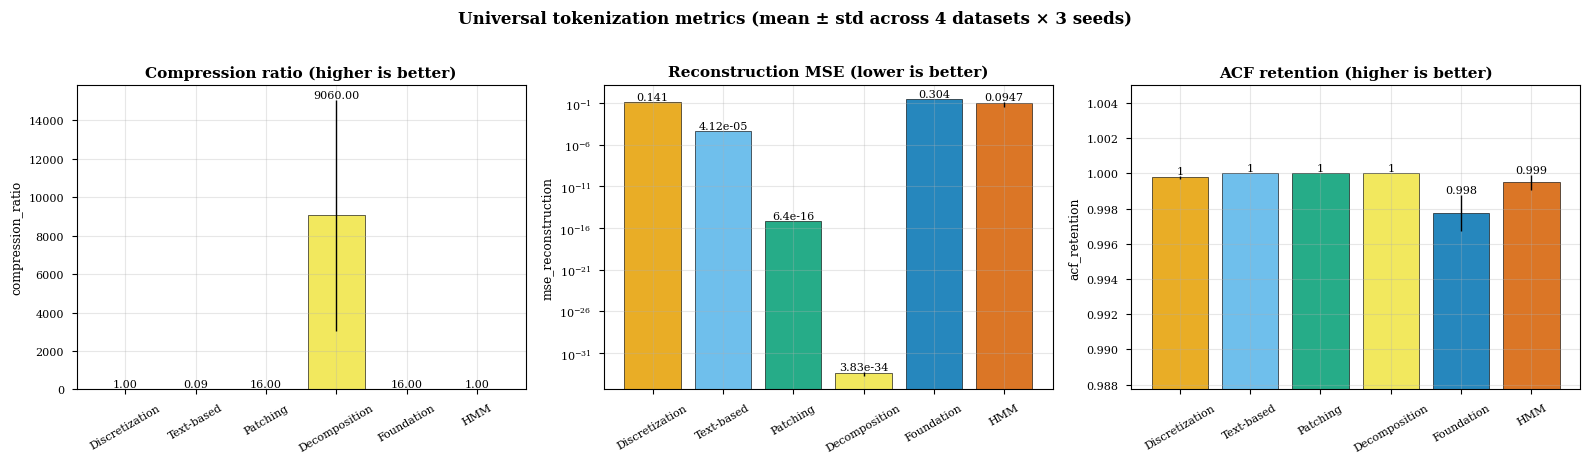

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metric, title in zip(axes, UNIVERSAL_METRICS, [
    'Compression ratio (higher is better)',
    'Reconstruction MSE (lower is better)',
    'ACF retention (higher is better)',
]):
    means = [df[df['technique']==t][metric].mean() for t in TECHNIQUES]
    stds = [df[df['technique']==t][metric].std() for t in TECHNIQUES]
    bars = ax.bar([TECH_DISPLAY[t] for t in TECHNIQUES], means, yerr=stds,
                  color=[TECH_COLOR[t] for t in TECHNIQUES],
                  alpha=0.85, edgecolor='black', linewidth=0.5,
                  capsize=4, error_kw={'linewidth': 1.0})
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    if metric == 'mse_reconstruction':
        ax.set_yscale('log')
    if metric == 'acf_retention':
        # Zoom-in to expose differences near the upper tail.
        finite_means = [m for m in means if not pd.isna(m)]
        if finite_means:
            ax.set_ylim(min(finite_means) - 0.01, 1.005)
    ax.grid(alpha=0.3, axis='y')
    # Bar annotations.
    for bar, m, s in zip(bars, means, stds):
        if not pd.isna(m):
            label = f'{m:.3g}' if metric != 'compression_ratio' else f'{m:.2f}'
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (s if not pd.isna(s) else 0),
                    label, ha='center', va='bottom', fontsize=8)

plt.suptitle('Universal tokenization metrics (mean ± std across 4 datasets × 3 seeds)',
             fontweight='bold', y=1.02)
plt.tight_layout()
for ext in ['png', 'pdf', 'svg']:
    fig.savefig(FIG_DIR / f'intrinsic_universal_3seeds.{ext}', dpi=300, bbox_inches='tight')
plt.show()

## 4. Figure — Discrete tokenization metrics (Discretization vs HMM)

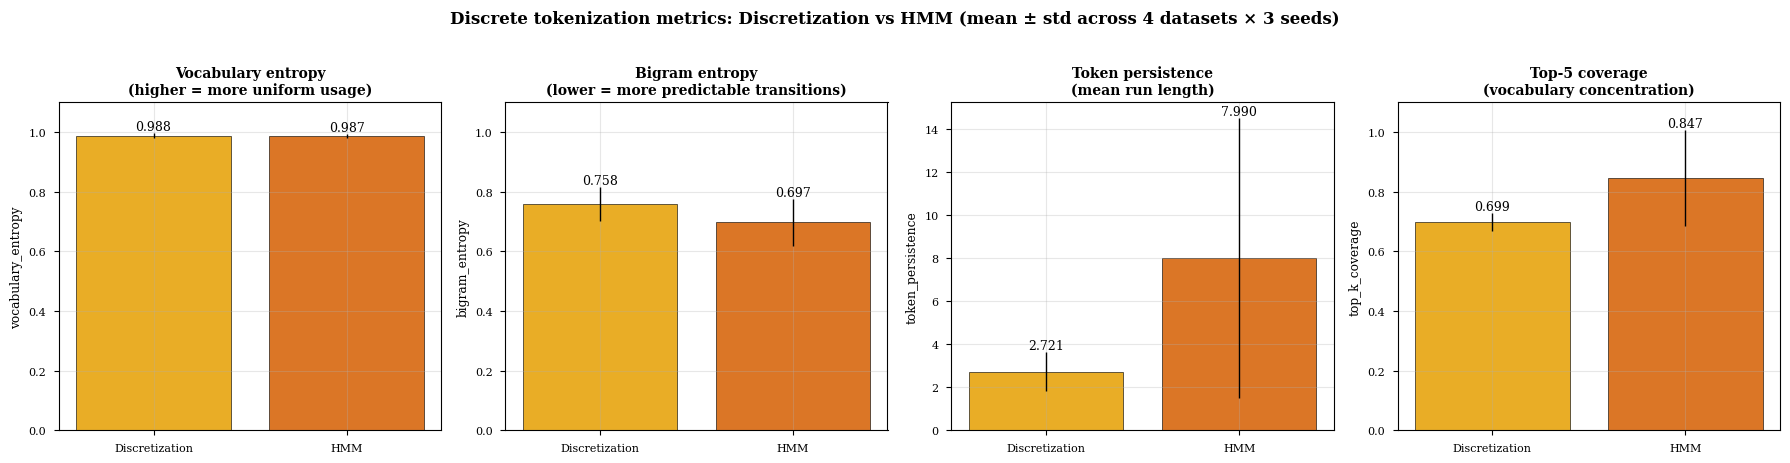

In [5]:
DISC_TECHS = ['discretization', 'hmm']
DISC_COLORS = [TECH_COLOR['discretization'], TECH_COLOR['hmm']]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, metric, title in zip(axes, DISCRETE_METRICS, [
    'Vocabulary entropy\n(higher = more uniform usage)',
    'Bigram entropy\n(lower = more predictable transitions)',
    'Token persistence\n(mean run length)',
    'Top-5 coverage\n(vocabulary concentration)',
]):
    means = [df[df['technique']==t][metric].mean() for t in DISC_TECHS]
    stds = [df[df['technique']==t][metric].std() for t in DISC_TECHS]
    bars = ax.bar([TECH_DISPLAY[t] for t in DISC_TECHS], means, yerr=stds,
                  color=DISC_COLORS, alpha=0.85, edgecolor='black',
                  linewidth=0.5, capsize=4, error_kw={'linewidth': 1.0})
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3, axis='y')
    if metric in ('vocabulary_entropy', 'bigram_entropy', 'top_k_coverage'):
        ax.set_ylim(0, 1.1)
    for bar, m, s in zip(bars, means, stds):
        if not pd.isna(m):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (s if not pd.isna(s) else 0),
                    f'{m:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Discrete tokenization metrics: Discretization vs HMM (mean ± std across 4 datasets × 3 seeds)',
             fontweight='bold', y=1.02)
plt.tight_layout()
for ext in ['png', 'pdf', 'svg']:
    fig.savefig(FIG_DIR / f'intrinsic_discrete_3seeds.{ext}', dpi=300, bbox_inches='tight')
plt.show()

## 5. Per-dataset table (consistency analysis)

Una métrica clave del paper: HMM es consistentemente superior a SAX en persistence cross-dataset.

In [6]:
# Pivot: technique × dataset, mean over 3 seeds, per metric.
for metric in ALL_METRICS:
    pivot_mean = df.groupby(['technique', 'dataset'])[metric].mean().unstack()
    pivot_std = df.groupby(['technique', 'dataset'])[metric].std().unstack()
    print(f'\n=== {metric} (avg over 3 seeds) ===')
    out = pd.DataFrame(index=pivot_mean.index)
    for ds in DATASETS:
        if ds in pivot_mean.columns:
            out[ds] = pivot_mean[ds].apply(lambda x: f'{x:.4f}' if not pd.isna(x) else '—') + '±' + \
                      pivot_std[ds].apply(lambda x: f'{x:.4f}' if not pd.isna(x) else '—')
    out['avg cross-ds'] = pivot_mean.mean(axis=1).apply(lambda x: f'{x:.4f}' if not pd.isna(x) else '—')
    print(out.to_string())


=== compression_ratio (avg over 3 seeds) ===
                           ETTh1             ETTh2            Weather       Electricity avg cross-ds
technique                                                                                           
decomposition   4320.0000±0.0000  4320.0000±0.0000  18432.0000±0.0000  9168.0000±0.0000    9060.0000
discretization     1.0000±0.0000     1.0000±0.0000      1.0000±0.0000     1.0000±0.0000       1.0000
foundation        16.0000±0.0000    16.0000±0.0000     16.0000±0.0000    16.0000±0.0000      16.0000
hmm                1.0000±0.0000     1.0000±0.0000      1.0000±0.0000     1.0000±0.0000       1.0000
patching          16.0000±0.0000    16.0000±0.0000     16.0000±0.0000    16.0000±0.0000      16.0000
text_based         0.0952±0.0000     0.0948±0.0000      0.0948±0.0000     0.0952±0.0000       0.0950

=== mse_reconstruction (avg over 3 seeds) ===
                        ETTh1          ETTh2        Weather    Electricity avg cross-ds
technique  

## 6. Figure — Cross-dataset robustness (perturbation stability)

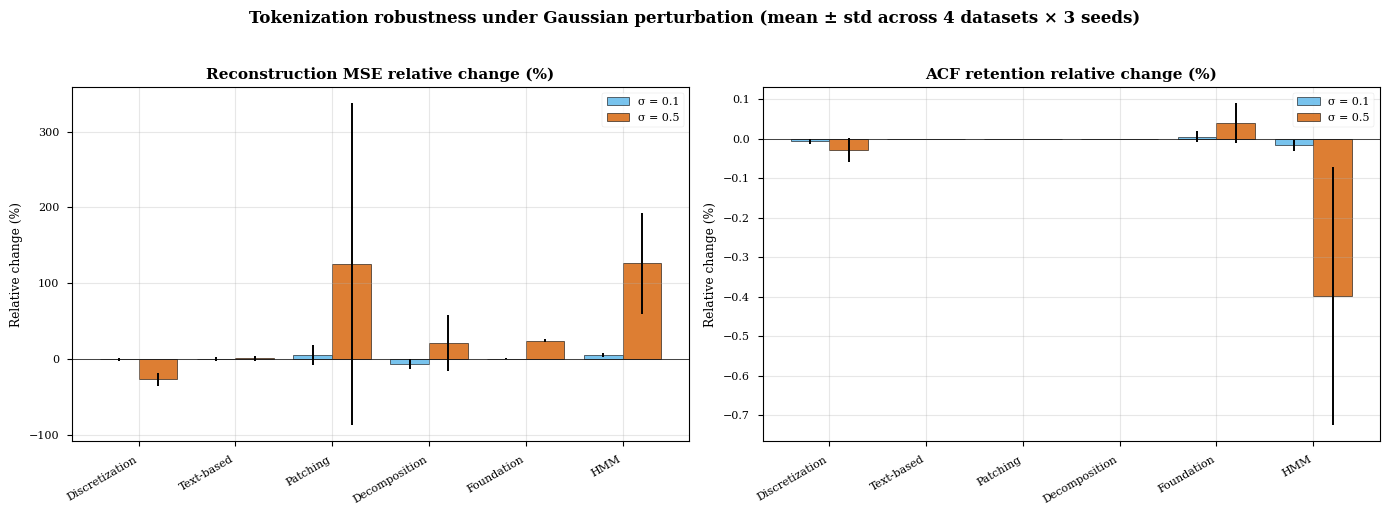

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes,
                              ['mse_change_rel', 'acf_change_rel'],
                              ['Reconstruction MSE relative change (%)',
                               'ACF retention relative change (%)']):
    n_t = len(TECHNIQUES)
    x = np.arange(n_t)
    width = 0.4
    for i, level in enumerate([0.1, 0.5]):
        means, stds = [], []
        for tech in TECHNIQUES:
            sub = df_robust[(df_robust['technique']==tech) & (df_robust['noise']==level)]
            means.append(sub[metric].mean() * 100)  # %
            stds.append(sub[metric].std() * 100)
        ax.bar(x + (i - 0.5) * width, means, width, yerr=stds,
               label=f'σ = {level}',
               color=COLORS[1] if i == 0 else COLORS[5],
               alpha=0.8, edgecolor='black', linewidth=0.5, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([TECH_DISPLAY[t] for t in TECHNIQUES], rotation=30, ha='right')
    ax.set_ylabel('Relative change (%)')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Tokenization robustness under Gaussian perturbation (mean ± std across 4 datasets × 3 seeds)',
             fontweight='bold', y=1.02)
plt.tight_layout()
for ext in ['png', 'pdf', 'svg']:
    fig.savefig(FIG_DIR / f'intrinsic_robustness_3seeds.{ext}', dpi=300, bbox_inches='tight')
plt.show()

## 7. Figure — Token-space distance under perturbation

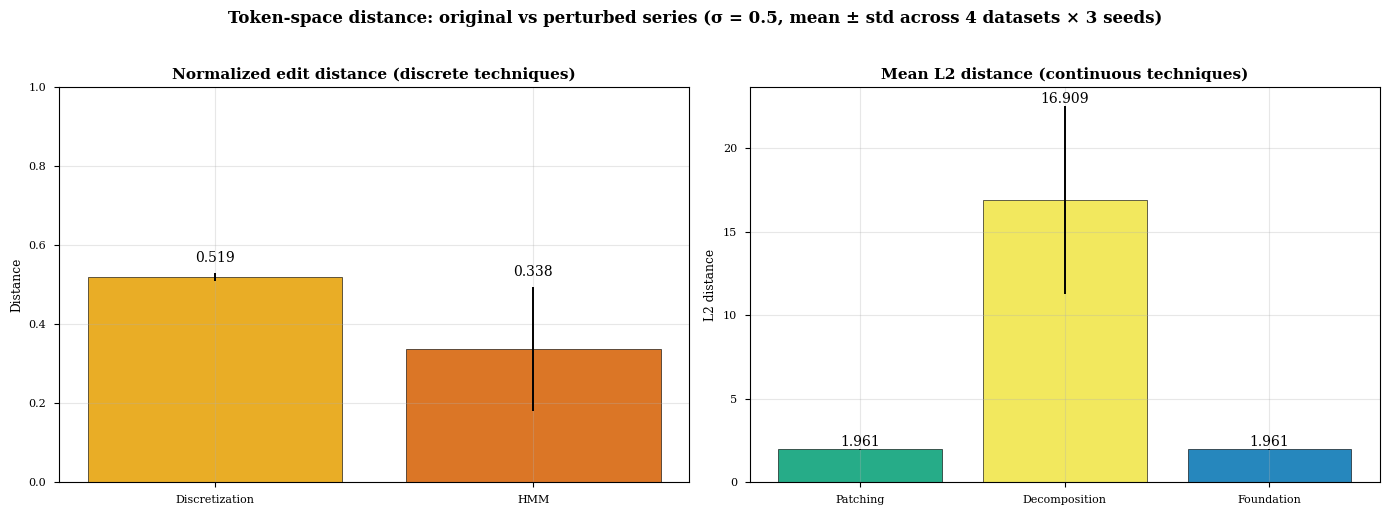

In [8]:
# Discrete techniques: normalized edit distance in [0, 1].
# Continuous techniques: mean L2 distance in token space.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discrete techniques.
ax = axes[0]
disc_techs = ['discretization', 'hmm']
means = [df_td[(df_td['technique']==t) & (df_td['kind']=='edit')]['value'].mean() for t in disc_techs]
stds = [df_td[(df_td['technique']==t) & (df_td['kind']=='edit')]['value'].std() for t in disc_techs]
bars = ax.bar([TECH_DISPLAY[t] for t in disc_techs], means, yerr=stds,
              color=[TECH_COLOR[t] for t in disc_techs],
              alpha=0.85, edgecolor='black', linewidth=0.5, capsize=4)
ax.set_title('Normalized edit distance (discrete techniques)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('Distance')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
for bar, m, s in zip(bars, means, stds):
    if not pd.isna(m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (s if not pd.isna(s) else 0) + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=10)

# Continuous techniques.
ax = axes[1]
cont_techs = ['patching', 'decomposition', 'foundation']
means = [df_td[(df_td['technique']==t) & (df_td['kind']=='l2')]['value'].mean() for t in cont_techs]
stds = [df_td[(df_td['technique']==t) & (df_td['kind']=='l2')]['value'].std() for t in cont_techs]
bars = ax.bar([TECH_DISPLAY[t] for t in cont_techs], means, yerr=stds,
              color=[TECH_COLOR[t] for t in cont_techs],
              alpha=0.85, edgecolor='black', linewidth=0.5, capsize=4)
ax.set_title('Mean L2 distance (continuous techniques)',
             fontweight='bold', fontsize=11)
ax.set_ylabel('L2 distance')
ax.grid(alpha=0.3, axis='y')
for bar, m, s in zip(bars, means, stds):
    if not pd.isna(m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (s if not pd.isna(s) else 0),
                f'{m:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Token-space distance: original vs perturbed series (σ = 0.5, mean ± std across 4 datasets × 3 seeds)',
             fontweight='bold', y=1.02)
plt.tight_layout()
for ext in ['png', 'pdf', 'svg']:
    fig.savefig(FIG_DIR / f'intrinsic_token_distance_3seeds.{ext}', dpi=300, bbox_inches='tight')
plt.show()

## 8. Executive summary

In [9]:
print('=' * 80)
print('RESUMEN EJECUTIVO - métricas intrínsecas (4 datasets × 3 seeds = 12 obs)')
print('=' * 80)

global_means = df.groupby('technique')[ALL_METRICS].mean()

print('\n1. COMPACIDAD/GRANULARIDAD:')
best = global_means['compression_ratio'].idxmax()
print(f'   Mejor compresión: {TECH_DISPLAY[best]} ({global_means.loc[best, "compression_ratio"]:.2f}x)')

print('\n2. RECONSTRUCCIÓN:')
best = global_means['mse_reconstruction'].idxmin()
print(f'   Menor pérdida: {TECH_DISPLAY[best]} (MSE={global_means.loc[best, "mse_reconstruction"]:.2e})')

print('\n3. DEPENDENCIAS TEMPORALES:')
best = global_means['acf_retention'].idxmax()
print(f'   Mejor preservación: {TECH_DISPLAY[best]} (ACF={global_means.loc[best, "acf_retention"]:.4f})')

print('\n4. DISCRETAS (HMM vs Discretization):')
for metric in DISCRETE_METRICS:
    h = global_means.loc['hmm', metric]
    s = global_means.loc['discretization', metric]
    if not pd.isna(h) and not pd.isna(s):
        winner = 'HMM' if (metric in ('vocabulary_entropy', 'token_persistence') and h > s) or \
                          (metric == 'bigram_entropy' and h < s) or \
                          (metric == 'top_k_coverage' and h > s) else 'SAX'
        print(f'   {metric:25}  HMM={h:.3f}  SAX={s:.3f}  → {winner}')

print('\n5. ROBUSTEZ (MSE change @ 0.5σ — menor = más estable):')
for tech in TECHNIQUES:
    sub = df_robust[(df_robust['technique']==tech) & (df_robust['noise']==0.5)]
    m = sub['mse_change_rel'].mean() * 100
    s = sub['mse_change_rel'].std() * 100
    print(f'   {TECH_DISPLAY[tech]:18}  Δ%MSE = {m:+.1f}% ± {s:.1f}%')

print('\n' + '=' * 80)

RESUMEN EJECUTIVO - métricas intrínsecas (4 datasets × 3 seeds = 12 obs)

1. COMPACIDAD/GRANULARIDAD:
   Mejor compresión: Decomposition (9060.00x)

2. RECONSTRUCCIÓN:
   Menor pérdida: Decomposition (MSE=3.83e-34)

3. DEPENDENCIAS TEMPORALES:
   Mejor preservación: Decomposition (ACF=1.0000)

4. DISCRETAS (HMM vs Discretization):
   vocabulary_entropy         HMM=0.987  SAX=0.988  → SAX
   bigram_entropy             HMM=0.697  SAX=0.758  → HMM
   token_persistence          HMM=7.990  SAX=2.721  → HMM
   top_k_coverage             HMM=0.847  SAX=0.699  → HMM

5. ROBUSTEZ (MSE change @ 0.5σ — menor = más estable):
   Discretization      Δ%MSE = -26.3% ± 8.5%
   Text-based          Δ%MSE = +1.3% ± 3.3%
   Patching            Δ%MSE = +125.1% ± 212.2%
   Decomposition       Δ%MSE = +21.3% ± 36.9%
   Foundation          Δ%MSE = +24.6% ± 1.8%
   HMM                 Δ%MSE = +126.4% ± 66.2%



## 9. CSV export

In [10]:
# 1) Long-form raw table (metrics per dataset/seed/technique).
df.to_csv(FIG_DIR / 'paper1_intrinsic_raw.csv', index=False)
df_robust.to_csv(FIG_DIR / 'paper1_intrinsic_robust_raw.csv', index=False)
df_td.to_csv(FIG_DIR / 'paper1_intrinsic_token_distance_raw.csv', index=False)

# 2) Cross-dataset aggregated table (one row per technique).
summary = df.groupby('technique')[ALL_METRICS].agg(['mean', 'std']).round(6)
summary.to_csv(FIG_DIR / 'paper1_intrinsic_summary_global.csv')
print('Saved:')
print(f'  {FIG_DIR / "paper1_intrinsic_raw.csv"}')
print(f'  {FIG_DIR / "paper1_intrinsic_robust_raw.csv"}')
print(f'  {FIG_DIR / "paper1_intrinsic_token_distance_raw.csv"}')
print(f'  {FIG_DIR / "paper1_intrinsic_summary_global.csv"}')

# 3) LaTeX-friendly summary table.
tex_lines = ['% Paper-1 intrinsic metrics — avg±std cross-dataset (4 ds × 3 seeds)']
for tech in TECHNIQUES:
    cells = [TECH_DISPLAY[tech]]
    for m in ALL_METRICS:
        mean = global_means.loc[tech, m]
        std = df[df['technique']==tech][m].std()
        if pd.isna(mean):
            cells.append('—')
        elif m == 'mse_reconstruction':
            cells.append(f'{mean:.2e}$\\pm${std:.2e}')
        else:
            cells.append(f'{mean:.4f}$\\pm${std:.4f}')
    tex_lines.append(' & '.join(cells) + ' \\\\')
(FIG_DIR / 'paper1_intrinsic_summary.tex').write_text('\n'.join(tex_lines))
print(f'  {FIG_DIR / "paper1_intrinsic_summary.tex"}')

Saved:
  notebooks/figures_paper1/paper1_intrinsic_raw.csv
  notebooks/figures_paper1/paper1_intrinsic_robust_raw.csv
  notebooks/figures_paper1/paper1_intrinsic_token_distance_raw.csv
  notebooks/figures_paper1/paper1_intrinsic_summary_global.csv
  notebooks/figures_paper1/paper1_intrinsic_summary.tex
